In [1]:
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import itertools
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

import dask.dataframe as dd
import arboreto.core as ac
from arboreto.algo import grnboost2, genie3
from distributed import Client

warnings.filterwarnings('ignore')
sc.settings.verbosity = 0

from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler

from qsim_cells.generative import (
    create_rotation_circuit,
    concatenate_circuits_with_separate_measurements,
    add_crx_and_measurements_to_circuit,
    create_binary_matrix,
    create_count_matrix_nbinom,
)
from qsim_cells.grn_utils import (
    prepare_gene_expression_data,
    calculate_correlation_and_adjacency,
)

# ── Dask patch (prevents empty-partition crash in arboreto) ───────────────────
if not hasattr(ac, '_original_from_delayed'):
    ac._original_from_delayed = ac.from_delayed

def _patched_from_delayed(dfs, *args, **kwargs):
    if not dfs or len(dfs) == 0:
        meta = kwargs.get('meta', None)
        if isinstance(meta, pd.DataFrame):
            return dd.from_pandas(meta, npartitions=1)
        return dd.from_pandas(pd.DataFrame(), npartitions=1)
    return ac._original_from_delayed(dfs, *args, **kwargs)

ac.from_delayed = _patched_from_delayed

try:
    client.close()
except Exception:
    pass
client = Client(processes=False)
print(f"Dask client ready: {client.dashboard_link}")

# ── Global seed ───────────────────────────────────────────────────────────────
MY_SEED = 42
np.random.seed(MY_SEED)

# ── Circuit angles (fraction × π) ─────────────────────────────────────────────
ANG_CT1 = np.array([0.2, 0.1, 0.4, 0.9, 0.8]) * np.pi
ANG_CT2 = np.array([0.2, 0.3, 0.2, 0.7, 0.5]) * np.pi

# ── Gene names ────────────────────────────────────────────────────────────────
GENE_NAMES_CT1 = ['g0', 'g1', 'g2', 'g3', 'g4']
GENE_NAMES_CT2 = ['g5', 'g6', 'g7', 'g8', 'g9']
QUANTUM_GENES  = GENE_NAMES_CT1 + GENE_NAMES_CT2

# ── Simulation parameters ─────────────────────────────────────────────────────
N_SHOTS = 2000          # quantum measurement shots (= number of simulated cells)
N_REPLICATES = 10       # independent seeded replicates

MU_V = np.array([5.] * 5)       # NB mean  — quantum genes
R_V  = np.array([1.] * 5)       # NB disp  — quantum genes

N_HKG  = 50
MU_HKG = np.full(N_HKG, 80.)   # NB mean  — housekeeping genes
R_HKG  = np.full(N_HKG, 6.)    # NB disp  — housekeeping genes

# ── GRN interaction maps ──────────────────────────────────────────────────────
INTERACTION_CASE1 = [(3, 5), (5, 7), (7, 0)]   # L1 — inter-state cascade
INTERACTION_CASE2 = [(2, 1)]                     # L2 — non-interacting control

# ── Benchmark configuration ───────────────────────────────────────────────────
THRESHOLDS       = [0.3, 0.4, 0.5, 0.6, 0.7]
TRUE_EDGES_CASE1 = {('g3','g5'), ('g5','g7'), ('g7','g0')}
TRUE_EDGES_CASE2 = {('g2','g1')}
COLOR_TRUE       = '#2E86C1'
COLOR_SPURIOUS   = '#E74C3C'

print(f"Setup complete.  MY_SEED={MY_SEED}  N_SHOTS={N_SHOTS}  N_REPLICATES={N_REPLICATES}")

Dask client ready: http://10.125.32.236:8787/status
Setup complete.  MY_SEED=42  N_SHOTS=2000  N_REPLICATES=10


## GRN Benchmark: 4 Methods × 2 Cases × 10 Seeds × 5 Thresholds

Evaluates Pearson, Spearman, GRNBoost2, and GENIE3 on qSimCells-generated data.

- **10 independently seeded replicates** (seeds 0–9) for reproducibility.
- **5 thresholds** τ ∈ {0.3, 0.4, 0.5, 0.6, 0.7}: applied to |Corr| for Pearson/Spearman,
  and to normalized importance score for GRNBoost2/GENIE3.
- **Edge frequency** = fraction of replicates in which each edge is recovered at a given threshold.
- Only **quantum genes** (g0–g9) are included; housekeeping genes are excluded from all edge sets.
- Blue bars = programmed CX edges (ground truth). Red bars = spurious correlations.

In [2]:
def is_true_edge(e, true_edges):
    """True if edge matches ground truth in either direction (undirected comparison)."""
    return (e in true_edges) or ((e[1], e[0]) in true_edges)


def get_quantum_edges_from_adj(adj, gene_list):
    """Extract undirected edges between quantum genes from a numpy adjacency matrix."""
    edges = set()
    q_idx = [i for i, g in enumerate(gene_list) if g in QUANTUM_GENES]
    for ii, jj in itertools.combinations(q_idx, 2):
        if adj[ii, jj] != 0:
            edges.add((gene_list[ii], gene_list[jj]))
    return edges


def get_quantum_edges_from_df(df, importance_col, tf_col, target_col, threshold):
    """
    Extract quantum-gene-only directed edges from a GRNBoost2/GENIE3 DataFrame,
    filtered by normalized importance >= threshold.
    HKG edges are excluded by requiring both TF and target to be in QUANTUM_GENES.
    """
    if df.empty:
        return set()
    mask = (
        (df[importance_col] >= threshold) &
        (df[tf_col].isin(QUANTUM_GENES)) &
        (df[target_col].isin(QUANTUM_GENES))
    )
    return set(df[mask].apply(lambda r: (r[tf_col], r[target_col]), axis=1))


def run_replicate(seed, ang_ct1, ang_ct2, interaction_map):
    """
    Runs the full pipeline for one seed.
    Returns {threshold: (pearson_edges, spearman_edges, grnboost2_edges, genie3_edges)}.
    All stochastic steps seeded via AerSimulator(seed_simulator=seed) + np.random.seed(seed).
    """
    np.random.seed(seed)

    # ── Quantum simulation ────────────────────────────────────────────────────
    circ1    = create_rotation_circuit(ang_ct1)
    circ2    = create_rotation_circuit(ang_ct2)
    combined = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final    = add_crx_and_measurements_to_circuit(combined, circ1.num_qubits, interaction_map)

    backend  = AerSimulator(seed_simulator=seed)
    pm       = generate_preset_pass_manager(backend=backend, optimization_level=1)
    result   = Sampler(mode=backend).run([pm.run(final)], shots=N_SHOTS).result()[0]
    counts1  = result.data.c_measure1.get_counts()
    counts2  = result.data.c_measure2.get_counts()

    # ── Count matrix construction ─────────────────────────────────────────────
    bin1 = create_binary_matrix(counts1);  cm1 = create_count_matrix_nbinom(bin1, MU_V, R_V)
    bin2 = create_binary_matrix(counts2);  cm2 = create_count_matrix_nbinom(bin2, MU_V, R_V)
    n    = cm1.shape[0]

    adata1 = ad.AnnData(X=cm1,
                        obs=pd.DataFrame(index=[f'c{i}_CT1' for i in range(n)]),
                        var=pd.DataFrame(index=GENE_NAMES_CT1))
    adata2 = ad.AnnData(X=cm2,
                        obs=pd.DataFrame(index=[f'c{i}_CT2' for i in range(n)]),
                        var=pd.DataFrame(index=GENE_NAMES_CT2))
    bin_hkg   = np.ones((n * 2, N_HKG), dtype=int)
    hkg_adata = ad.AnnData(X=create_count_matrix_nbinom(bin_hkg, MU_HKG, R_HKG),
                           obs=pd.DataFrame(index=list(adata1.obs_names) + list(adata2.obs_names)),
                           var=pd.DataFrame(index=[f'HKG_{i}' for i in range(N_HKG)]))

    merged = ad.concat([adata1, adata2], axis=0, join='outer', label='BatchID', keys=['CT1','CT2'])
    merged.X[np.isnan(merged.X)] = 0
    adata  = ad.concat([merged, hkg_adata], axis=1, join='inner', merge='unique')

    # ── Preprocessing ─────────────────────────────────────────────────────────
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.scale(adata, max_value=10)

    # ── Tree-based methods (run once per seed, threshold swept below) ─────────
    expression_df = adata.to_df()
    tf_list = list(expression_df.columns)

    df_gb2 = grnboost2(expression_data=expression_df, tf_names=tf_list, verbose=False)
    df_g3  = genie3(expression_data=expression_df,   tf_names=tf_list, verbose=False)

    for df in [df_gb2, df_g3]:
        df['importance_norm'] = (df['importance'] / df['importance'].max()
                                 if not df.empty and df['importance'].max() > 0 else 0.0)

    # ── Correlation-based methods ─────────────────────────────────────────────
    gexp = prepare_gene_expression_data(adata)

    # ── Threshold sweep ───────────────────────────────────────────────────────
    results = {}
    for thr in THRESHOLDS:
        g_p, p_adj = calculate_correlation_and_adjacency(gexp, 'pearson',  threshold=thr)
        g_s, s_adj = calculate_correlation_and_adjacency(gexp, 'spearman', threshold=thr)

        results[thr] = (
            get_quantum_edges_from_adj(p_adj, list(g_p)),                                # Pearson
            get_quantum_edges_from_adj(s_adj, list(g_s)),                                # Spearman
            get_quantum_edges_from_df(df_gb2, 'importance_norm', 'TF', 'target', thr),  # GRNBoost2
            get_quantum_edges_from_df(df_g3,  'importance_norm', 'TF', 'target', thr),  # GENIE3
        )
    return results


# ── Execute N_REPLICATES seeds × 2 cases ──────────────────────────────────────
methods   = ['pearson', 'spearman', 'grnboost2', 'genie3']
edge_freq = {
    case: {m: {thr: defaultdict(int) for thr in THRESHOLDS} for m in methods}
    for case in ['Case1', 'Case2']
}

for seed in range(N_REPLICATES):
    print(f'Seed {seed} ...', end=' ', flush=True)
    for case, imap in [('Case1', INTERACTION_CASE1), ('Case2', INTERACTION_CASE2)]:
        rep = run_replicate(seed, ANG_CT1, ANG_CT2, imap)
        for thr in THRESHOLDS:
            p_e, s_e, gb2_e, g3_e = rep[thr]
            for e in p_e:   edge_freq[case]['pearson'][thr][e]   += 1
            for e in s_e:   edge_freq[case]['spearman'][thr][e]  += 1
            for e in gb2_e: edge_freq[case]['grnboost2'][thr][e] += 1
            for e in g3_e:  edge_freq[case]['genie3'][thr][e]    += 1
    print('done')

print('\nAll replicates complete.')

Seed 0 ... Number of non-zero elements (connections): 38
Number of non-zero elements (connections): 46
Number of non-zero elements (connections): 30
Number of non-zero elements (connections): 30
Number of non-zero elements (connections): 8
Number of non-zero elements (connections): 20
Number of non-zero elements (connections): 0
Number of non-zero elements (connections): 2
Number of non-zero elements (connections): 0
Number of non-zero elements (connections): 0
Number of non-zero elements (connections): 14
Number of non-zero elements (connections): 22
Number of non-zero elements (connections): 8
Number of non-zero elements (connections): 8
Number of non-zero elements (connections): 6
Number of non-zero elements (connections): 8
Number of non-zero elements (connections): 2
Number of non-zero elements (connections): 2
Number of non-zero elements (connections): 0
Number of non-zero elements (connections): 2
done
Seed 1 ... Number of non-zero elements (connections): 44
Number of non-zero e

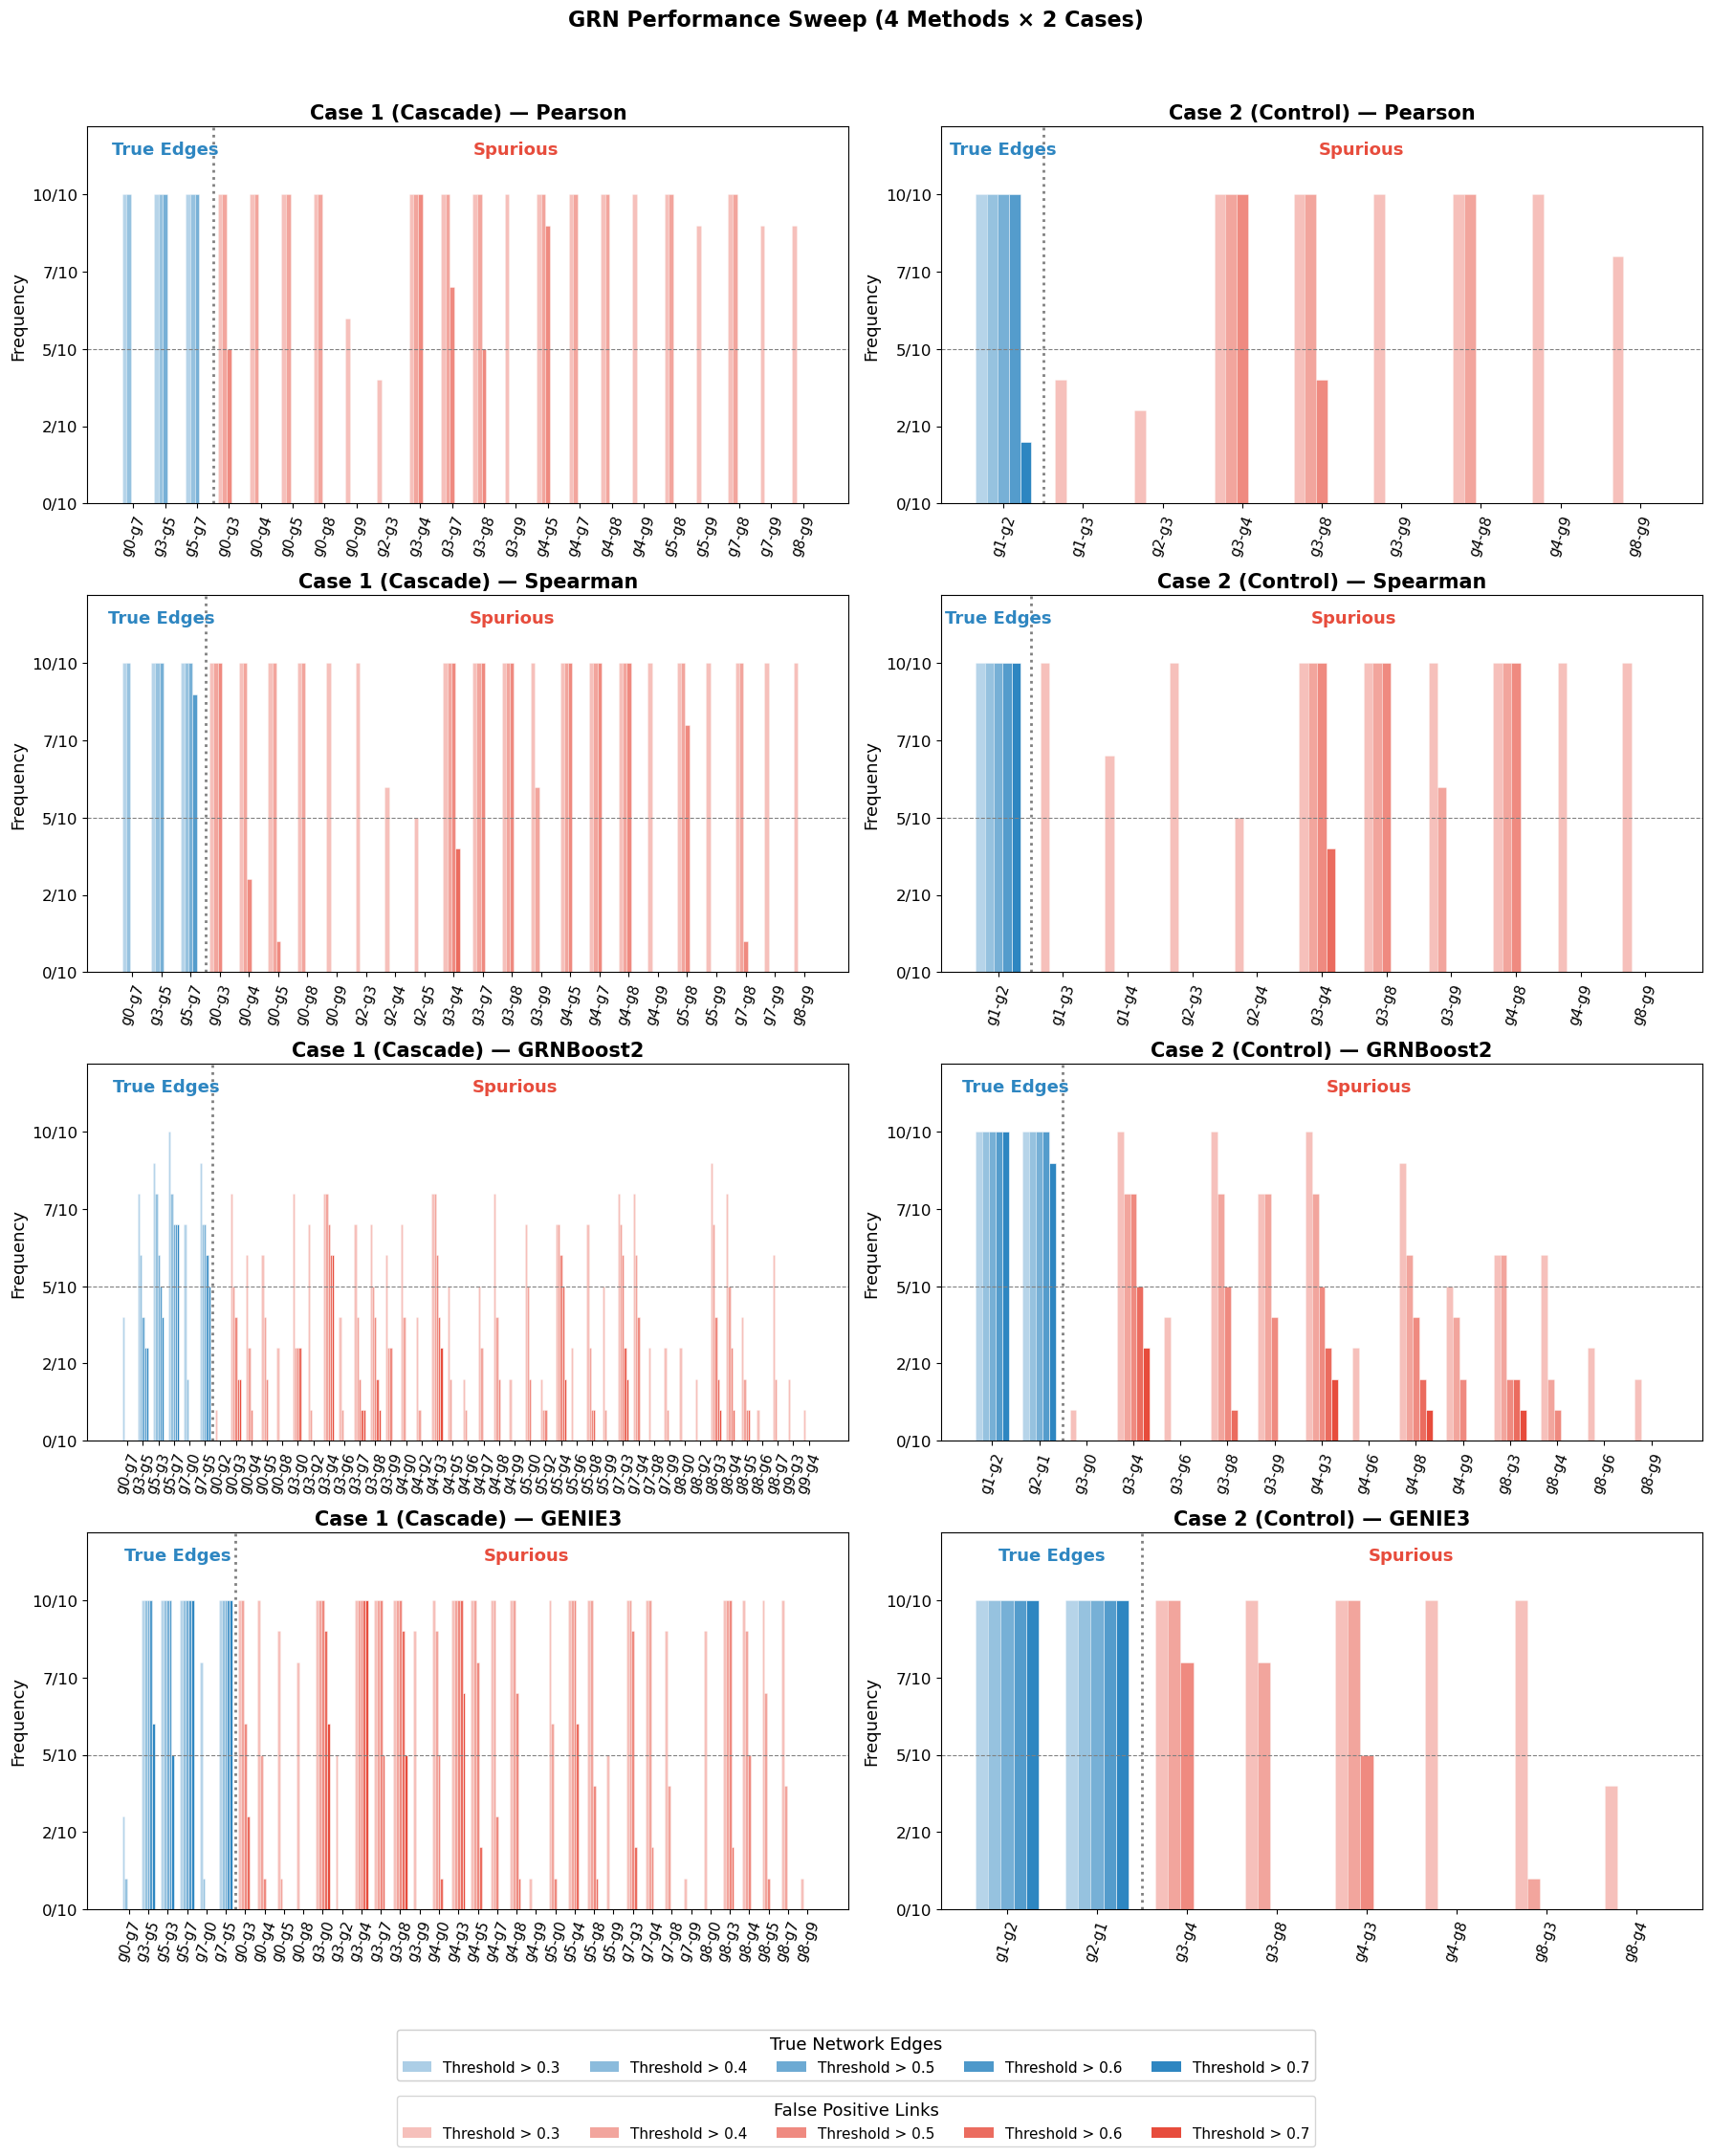

Saved complete_4method_frequency_sweep.pdf


In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_sweep_frequency(ax, case, method, true_edges, title):
    all_edges = set()
    for thr in THRESHOLDS:
        all_edges |= set(edge_freq[case][method][thr].keys())
    if not all_edges:
        ax.set_title(title + '\n(no edges found)', fontsize=12, fontweight='bold')
        return

    true_l     = sorted([e for e in all_edges if     is_true_edge(e, true_edges)], key=str)
    spurious_l = sorted([e for e in all_edges if not is_true_edge(e, true_edges)], key=str)
    ordered    = true_l + spurious_l
    labels     = [f'{e[0]}-{e[1]}' for e in ordered]
    x          = range(len(ordered))
    bar_w      = 0.14
    alphas     = [0.35, 0.50, 0.65, 0.82, 1.0]   # lightest = τ 0.3, darkest = τ 0.7

    for ti, thr in enumerate(THRESHOLDS):
        counts  = [edge_freq[case][method][thr].get(e, 0) for e in ordered]
        heights = [c / N_REPLICATES for c in counts]
        colors  = [COLOR_TRUE if is_true_edge(e, true_edges) else COLOR_SPURIOUS
                   for e in ordered]
        offset  = (ti - len(THRESHOLDS) / 2 + 0.5) * bar_w
        ax.bar([xi + offset for xi in x], heights, width=bar_w,
               color=colors, edgecolor='white', linewidth=0.4, alpha=alphas[ti])

    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xticks(list(x))
    
    # 90 degrees with center alignment perfectly centers the label under its bar cluster
    ax.set_xticklabels(labels, rotation=70, ha='center', fontsize=11)
    
    ax.set_ylim(0, 1.22)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels([f'{int(v*N_REPLICATES)}/{N_REPLICATES}' for v in [0, 0.25, 0.5, 0.75, 1.0]],
                       fontsize=12)
    ax.set_ylabel('Frequency', fontsize=13)
    ax.set_title(title, fontsize=15, fontweight='bold')

    if true_l:
        ax.axvline(len(true_l) - 0.5, color='gray', linestyle=':', linewidth=2)
        ax.text(len(true_l) / 2 - 0.5, 1.13, 'True Edges',
                ha='center', fontsize=13, color=COLOR_TRUE, fontweight='bold')
    if spurious_l:
        ax.text(len(true_l) + len(spurious_l) / 2 - 0.5, 1.13, 'Spurious',
                ha='center', fontsize=13, color=COLOR_SPURIOUS, fontweight='bold')


# Height bumped up to 23 to securely accommodate the stacked legends beneath the plots
fig, axes = plt.subplots(4, 2, figsize=(18, 23))
fig.suptitle('GRN Performance Sweep (4 Methods × 2 Cases)',
             fontsize=16, fontweight='bold', y=0.98)

plot_sweep_frequency(axes[0,0], 'Case1', 'pearson',   TRUE_EDGES_CASE1, 'Case 1 (Cascade) — Pearson')
plot_sweep_frequency(axes[0,1], 'Case2', 'pearson',   TRUE_EDGES_CASE2, 'Case 2 (Control) — Pearson')
plot_sweep_frequency(axes[1,0], 'Case1', 'spearman',  TRUE_EDGES_CASE1, 'Case 1 (Cascade) — Spearman')
plot_sweep_frequency(axes[1,1], 'Case2', 'spearman',  TRUE_EDGES_CASE2, 'Case 2 (Control) — Spearman')
plot_sweep_frequency(axes[2,0], 'Case1', 'grnboost2', TRUE_EDGES_CASE1, 'Case 1 (Cascade) — GRNBoost2')
plot_sweep_frequency(axes[2,1], 'Case2', 'grnboost2', TRUE_EDGES_CASE2, 'Case 2 (Control) — GRNBoost2')
plot_sweep_frequency(axes[3,0], 'Case1', 'genie3',    TRUE_EDGES_CASE1, 'Case 1 (Cascade) — GENIE3')
plot_sweep_frequency(axes[3,1], 'Case2', 'genie3',    TRUE_EDGES_CASE2, 'Case 2 (Control) — GENIE3')

alphas = [0.35, 0.50, 0.65, 0.82, 1.0]
true_handles     = [mpatches.Patch(facecolor=COLOR_TRUE,     alpha=a, label=f'Threshold > {t}')
                    for a, t in zip(alphas, THRESHOLDS)]
spurious_handles = [mpatches.Patch(facecolor=COLOR_SPURIOUS, alpha=a, label=f'Threshold > {t}')
                    for a, t in zip(alphas, THRESHOLDS)]

# STACKED LEGENDS LAYOUT: 
# Centered horizontally at 0.5, spaced safely on the vertical (y) axis.
leg1 = fig.legend(handles=true_handles, title='True Network Edges',
                  loc='lower center', bbox_to_anchor=(0.5, 0.035),
                  ncol=5, fontsize=11, title_fontsize=13, frameon=True)
leg2 = fig.legend(handles=spurious_handles, title='False Positive Links',
                  loc='lower center', bbox_to_anchor=(0.5, 0.005),
                  ncol=5, fontsize=11, title_fontsize=13, frameon=True)
fig.add_artist(leg1)

# Shifted the bottom margin up to 0.085 to cleanly clear the stacked legend heights
plt.tight_layout(rect=[0, 0.085, 1, 0.96])

plt.savefig('complete_4method_frequency_sweep.pdf', bbox_inches='tight')
plt.show()
print('Saved complete_4method_frequency_sweep.pdf')